In [1]:
import warnings
from linear_operator.utils.warnings import NumericalWarning
from botorch.exceptions import OptimizationWarning

ignore_warnings: list[type] = [
    NumericalWarning,
    OptimizationWarning,
    RuntimeWarning
]

for warning in ignore_warnings:
    warnings.filterwarnings(action="ignore", category=warning)

In [2]:
from ddo_suite.problems import (
    Sphere, 
    ExothermicCstr,
    PidTuning,
    WilliamsOtto
    )
from ddo_suite.algorithms import (
    ALGORITHM_IDS,
    __all__,
    random_search,
    safeopt,
    goose
    )
from ddo_suite.experiments import (
    run_benchmark, 
    aggregate_results, 
    AggregatedResults,
    ExperimentCache,
    BenchmarkResults
    )

from safebo_simpl.wrappers.ddosuite_wrapper import (
    DDOSuite_AlgorithmWrapper,
    DDOSuite_ObjectiveWrapper
)
from safebo_simpl.models import *
from safebo_simpl.util.generics import SafeBOAlgorithm
from safebo_simpl.util.params import BOParams

from typing import Callable

import torch
from torch import Tensor

import numpy as np
from numpy import typing as npt

dtype: torch.dtype = torch.float64
device: torch.device = torch.device("cpu")

def _wrapper_factory[T_Algorithm: SafeBOAlgorithm, T_Params: BOParams](
    algorithm: type[T_Algorithm],
    params: T_Params,
    config_name: str = "default",
) -> tuple[DDOSuite_AlgorithmWrapper, str]:
    wrapper: DDOSuite_AlgorithmWrapper = DDOSuite_AlgorithmWrapper(
        algorithm=algorithm,
        params=params,
        dtype=dtype,   # Global scope
        device=device  # Global scope
    )
    base_name = algorithm.__name__.lower().replace(' ', '_')
    id: str = f"custom_{base_name}_{config_name}"
    return (wrapper, id)

# ----------------------------
# ------ Generic Params ------
# ----------------------------

generic_state: BOParams = BOParams()
# Sampling
generic_state.sampling.initial_candidates = 2 + 4
generic_state.sampling.batch_size = 16
generic_state.convergence.confidence_level = 3.

# Constraints
generic_state.constraints.constraints = []

# Data prms
generic_state.data.negate = False


# --------------------------
# ------ GPsTR Params ------
# --------------------------

GPsTR_state: BOParams_GPsTR = BOParams_GPsTR()
GPsTR_state.sampling = generic_state.sampling
GPsTR_state.constraints = generic_state.constraints
GPsTR_state.data = generic_state.data

pairs: list[tuple[type[SafeBOAlgorithm], BOParams]] = [
    #(GoOSEV2, generic_state),
    #(GoOSE, generic_state),
    #(SafeOpt, generic_state),
    #(GPsTR, GPsTR_state),
]

pairs_cached: list[tuple[type[SafeBOAlgorithm], BOParams]] = [
    (GoOSEV2_HypercubeX, generic_state),
    (GoOSEV2_HypercubeZ, generic_state),
    (GoOSEV2_BScheduler, generic_state),
    (GoOSEV2_topK, generic_state),
    (GoOSEV2_Aoffset, generic_state),
]

vals: set[str] = set(ALGORITHM_IDS.values())
custom_algorithms: list[Callable] = []

cached_custom_algorithms: list[Callable] = []

for alg, state in pairs:
    wrapper, id = _wrapper_factory(algorithm=alg, params=state,)
    custom_algorithms.append(wrapper)
    ALGORITHM_IDS[wrapper] = id

for alg, state in pairs_cached:
    wrapper, id = _wrapper_factory(algorithm=alg, params=state,)
    cached_custom_algorithms.append(wrapper)
    ALGORITHM_IDS[wrapper] = id

ModuleNotFoundError: No module named 'ddo_suite'

In [ ]:
problems: list[tuple[int, list[type]]] = \
    [
        #Sphere,
        (2, [ExothermicCstr]),
        (3, [PidTuning]),
        (2, [WilliamsOtto])
    ]
algorithms: list[Callable] = \
    [
        #random_search,
        #safeopt,
        goose,
        
    ]
algorithms.extend(cached_custom_algorithms)

cache: ExperimentCache | None = None #ExperimentCache("cache_all_100_violations")
#results: BenchmarkResults = run_benchmark(
#    problems=problems,
#    algorithms=algorithms,
#    n_x=2, seeds=range(10), max_evals=(100), cache=cache, verbose=True
#)

result_baseline: BenchmarkResults = BenchmarkResults()
result_custom: BenchmarkResults = BenchmarkResults()

for (n_x, prblms) in problems:
    result_baseline += run_benchmark(
        problems=prblms,
        algorithms=algorithms,
        n_x=n_x, seeds=range(10), max_evals=(100), cache=ExperimentCache("baseline_cache"), verbose=True
    )
    if not custom_algorithms:
        continue
    result_custom += run_benchmark(
        problems=prblms,
        algorithms=custom_algorithms,
        n_x=n_x, seeds=range(10), max_evals=(100), cache=None, verbose=True
    )

COMPUTED - problem: (exothermic_cstr), algorithm: (goose), seed: (4)  elapsed: 43.01 sec
  best_f: (-1.0805842154544392)
  f_list: ([-0.050718801061436766, -0.02812073785973859, -0.03275198054386436, -0.027451917695287, -0.03369963227229493, -0.014309707743769646, -0.01926307670697279, -0.038248627458842215, -0.03198649363370587, -0.23191246999984197, -0.013032867473575209, -0.03829742176607796, -0.02943465926821115, -0.04460382529316937, -0.07094215412036986, -0.0805289789491655, -0.06733860716067719, -0.03831887041922986, -0.03287026331657708, -0.0695667364617594, -0.0889112800640699, -0.10574223400499733, -0.1258536444322344, -0.14663251945161496, -0.17556449809865185, -1.0805842154544392, -0.02500556887988974, -0.03563526323165685, -0.02286610858840218, -0.023110037929931666, -0.03013144490113809, -0.19727406011922768, -0.03289690521352513, -0.026187160616169027, -0.02700067390901304, -0.028297636708457405, -0.027989060374965423, -0.18092465731039556, -0.018291924604584793, -0.0094

[<Figure size 1100x760 with 4 Axes>]

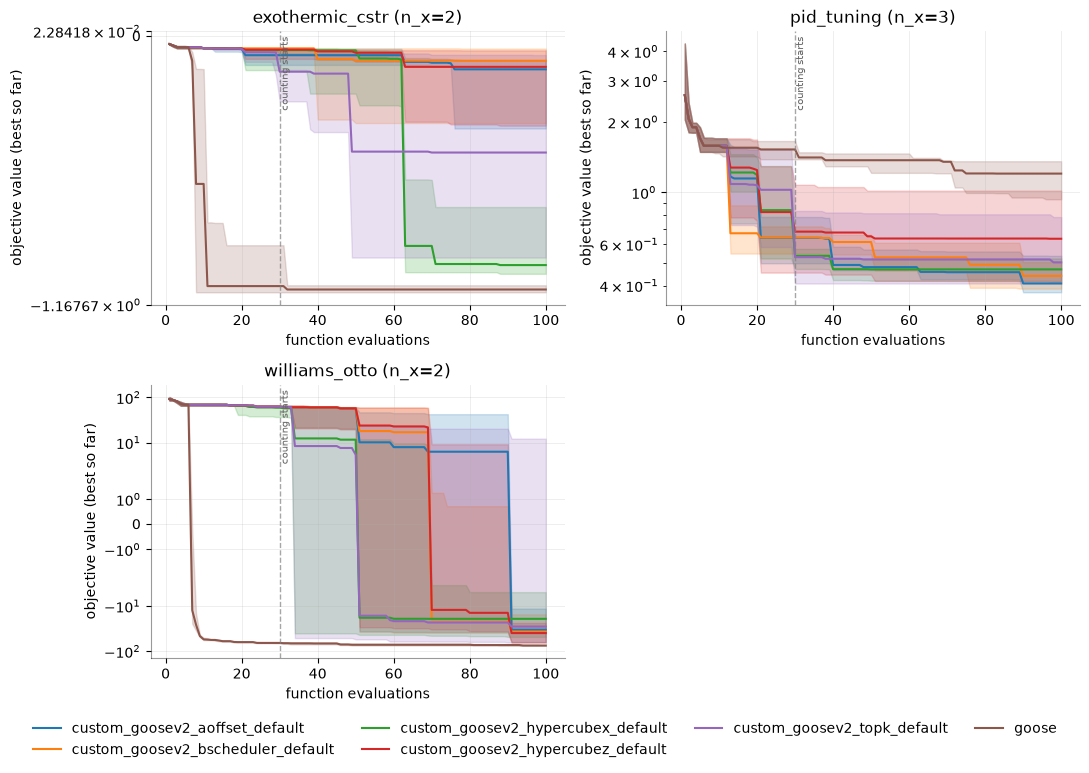

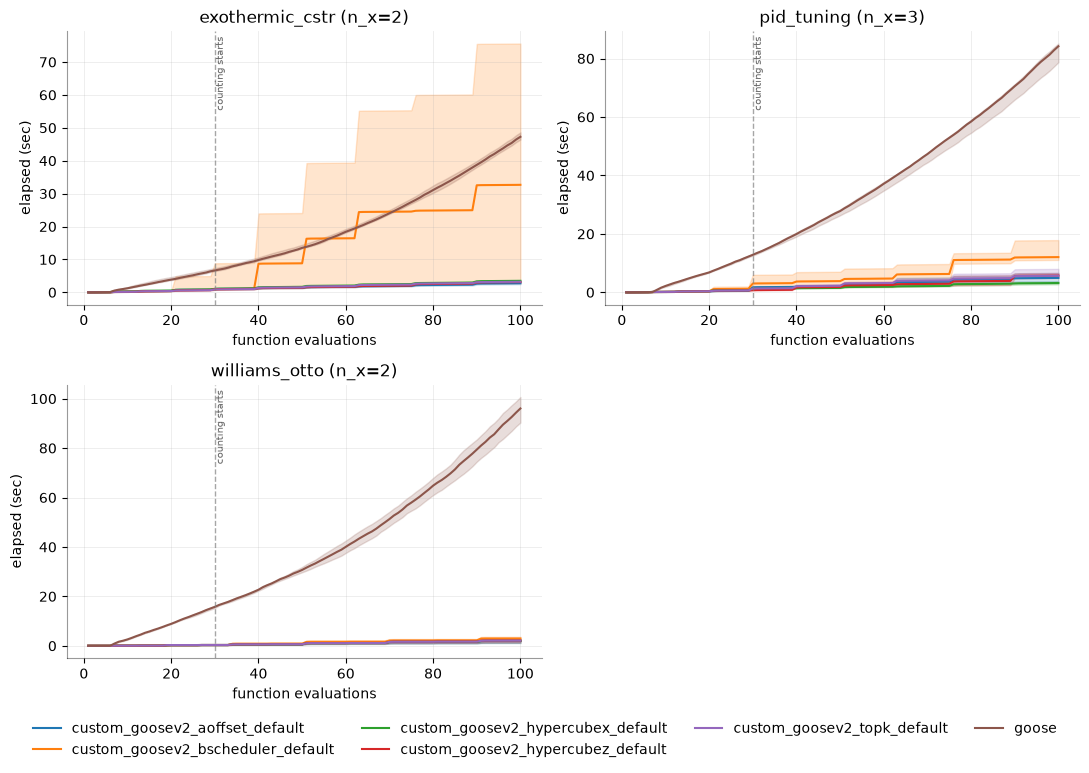

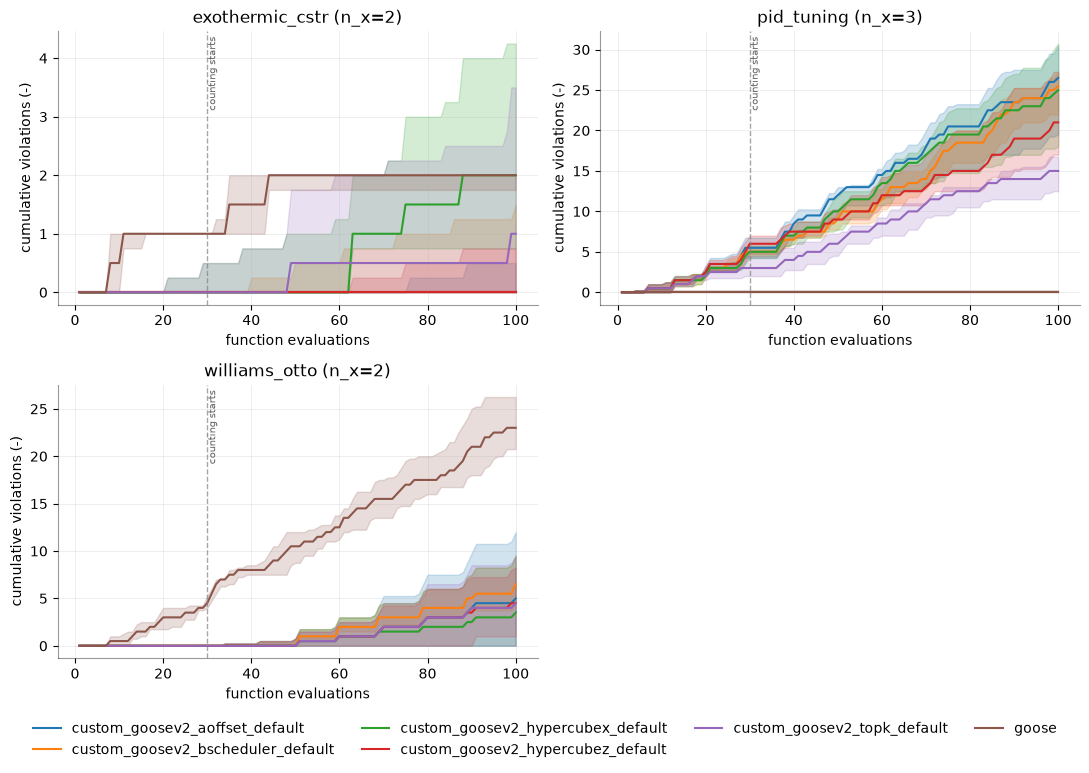

In [ ]:
from safebo_simpl.wrappers.ddosuite_graphing import (
    plot_all_convergence,
    plot_all_elapsed,
    plot_all_cumulative_elapsed,
    plot_all_cumulative_violations,
)

agg = aggregate_results(results=result_baseline + result_custom, ignore_nonexistent_attributes=False)
plot_all_convergence(agg)
plot_all_elapsed(agg, log_y=False)
plot_all_cumulative_violations(agg)
